# Experiment2 材料科学中的线性方法及分类学习

**Name:** JiaxinLIN 林嘉馨
**Student ID:** 23302040  
**Experiment Title:** Applying Python to process data learning  
**Institution:** School of Material, SYSU  

---

# Abstract
本实验旨在综合应用机器学习方法解决材料科学中的数据分析问题，涵盖特征工程、监督学习和无监督学习三大核心任务。

首先，从2022年材料数据库出发，对包含formation_energy_per_atom和band_gap等性质的材料数据进行预处理和特征构建。通过去重、过滤正形成能数据，并结合
元素属性数据库，提取成分平均值、最大值和最小值三类统计特征，构建了33维特征矩阵，为后续建模奠定基础。

其次，针对材料性质预测任务，建立了多种回归和分类模型。在formation_energy预测中，对比了线性回归、Ridge和LASSO三种方法，LASSO回归表现最优（测试集RMSE=0.192），并通过征分析识别出8个无贡献特征。在金属性判断任务中，Logistic回归达到73.53%的准确率，但结果表明仅依赖化学式信息存在局限性，无法充分捕捉晶体结构等关键信息。

最后，在Pd/Ru双金属纳米催化剂显微图像分析中，应用K-means和DBSCAN两种聚类算法识别金属颗粒分布。通过肘部法则和K-distance图分别确定最优参数，K-means实现了颗粒的初步分组，而DBSCAN凭借基于密度的聚类机制，成功识别了85个不规则形状的颗粒团簇并自动排除796个噪声点，更适合显微图像分析场景。

本实验完整展示了机器学习在材料数据分析中的应用流程，从特征提取、模型训练到结果解释，为材料性质预测和显微结构分析提供了有效的计算方法。

# Q1- 探索性数据分析

In [1]:
import pandas as pd

orig_data = pd.read_csv("data2022.csv", na_filter=False)

orig_data

,Unnamed: 0,task_id,formula,formation_energy_per_atom,e_above_hull,band_gap,has_bandstructure
0,297,mp-570140,AuBr,-0.125181,0.011579,1.9716,True
1,573,mp-1206190,ZnI6,0.387945,0.652470,0.1076,False
2,579,mp-1208424,TeBr4,-0.390060,0.000000,2.5202,False
3,738,mp-570480,TcBr4,-0.404404,0.000000,0.6025,True
4,880,mp-1064459,PBr,1.067789,1.327882,0.0000,False
...,...,...,...,...,...,...,...
676,118973,mp-974371,Rh3Br,0.670866,0.820678,0.0000,True
677,121600,mp-867231,TbI3,-1.382737,0.000000,2.0937,True
678,121602,mp-867247,TbBr3,-1.860767,0.000000,2.8570,True
679,121619,mp-867355,TeBr2,-0.186842,0.140200,0.6529,True


1. 数据集中共有多少种材料？

In [2]:
num_materials = len(orig_data)
print("数据集中共有材料数量：", num_materials)

数据集中共有材料数量： 681


2. 有多少种唯一的化学式？

In [3]:
num_unique_formula = orig_data["formula"].nunique()
print("数据集中有唯一化学式数量：", num_unique_formula)

数据集中有唯一化学式数量： 392


3. 数据集中包含多少种元素？

In [4]:
from pymatgen.core import Composition

elements = set()

for f in orig_data["formula"]:
    comp = Composition(f)
    for el in comp.elements:
        elements.add(el.symbol)

print("元素种类数量：", len(elements))
print("元素列表：", sorted(elements))

元素种类数量： 80
元素列表： ['Ac', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Ce', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'Os', 'P', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']


4. 统计每种元素在材料中出现的次数，排序后绘制条形图，展示前10个最
常见元素的出现频次。

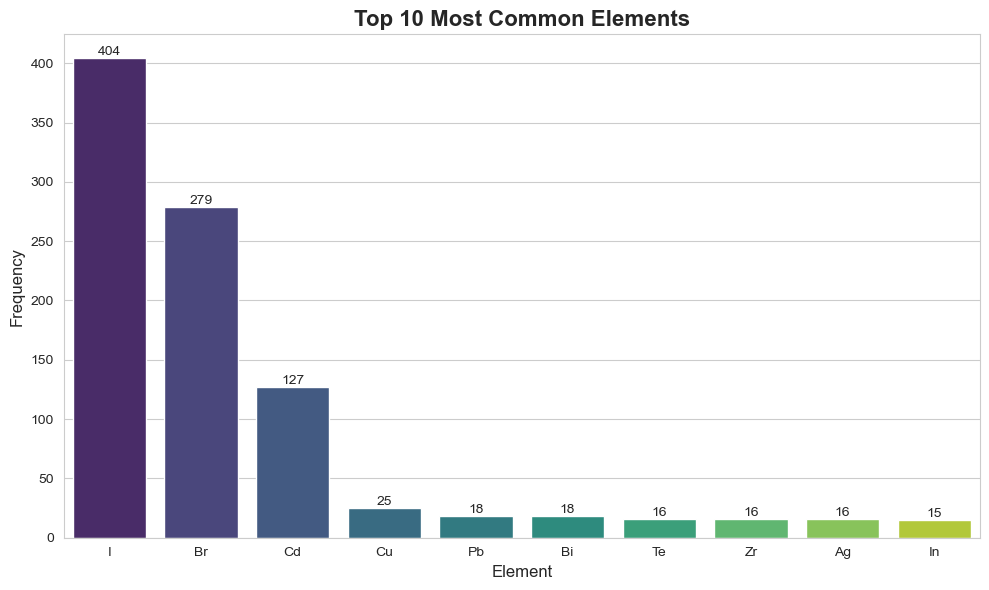


Top 10 most common elements and their frequencies:
I: 404
Br: 279
Cd: 127
Cu: 25
Pb: 18
Bi: 18
Te: 16
Zr: 16
Ag: 16
In: 15


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Count occurrences of each element
element_counter = Counter()

for f in orig_data["formula"]:
    comp = Composition(f)
    for el in comp.elements:
        element_counter[el.symbol] += 1

# Get top 10 most common elements
top_10_elements = element_counter.most_common(10)

# Prepare data for plotting
elements_list = [item[0] for item in top_10_elements]
counts_list = [item[1] for item in top_10_elements]

# Set plot style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=elements_list, y=counts_list, hue=elements_list, palette="viridis", legend=False)

# Add title and labels
plt.title("Top 10 Most Common Elements", fontsize=16, fontweight='bold')
plt.xlabel("Element", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add count values on top of bars
for i, count in enumerate(counts_list):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print("\nTop 10 most common elements and their frequencies:")
for element, count in top_10_elements:
    print(f"{element}: {count}")

# Q2- 数据清洗与特征计算

1. 去重处理，显示材料数量多于唯一化学式数量（同一化学式可能存在多
种晶型）。由于成分特征无法预测同一化学式的多组性质值，需过滤数据：保留
每个化学式中“每个原子形成能”最低的行。过滤后剩余多少材料？

In [6]:
# —— 去重处理：按化学式分组，保留每个原子形成能最低的一行 ——

# 过滤操作：按 formation_energy_per_atom 升序排列
filtered_data = (
    orig_data
    .sort_values("formation_energy_per_atom")
    .groupby("formula", as_index=False)
    .first()   # 每组保留第一行（形成能最低）
)

print("原始材料数量：", len(orig_data))
print("唯一化学式数量：", orig_data['formula'].nunique())
print("过滤后材料数量（保留形成能最低者）：", len(filtered_data))

# 查看前几行
filtered_data.head()

原始材料数量： 681
唯一化学式数量： 392
过滤后材料数量（保留形成能最低者）： 392


,formula,Unnamed: 0,task_id,formation_energy_per_atom,e_above_hull,band_gap,has_bandstructure
0,Ac3Br,8101,mp-1183119,-0.123453,0.575916,0.0000,False
1,Ac3I,26573,mp-1183096,-0.138439,0.367647,0.0000,False
2,AcBr3,70294,mp-27972,-2.098107,0.000000,4.1045,True
3,AcI3,112962,mp-861867,-1.518260,0.000000,2.5888,True
4,Ag2Br3,18480,mp-862982,-0.278481,0.019988,0.0000,False


2. 过滤正形成能数据
正形成能通常表示计算未收敛。进一步过滤删除所有形成能为正的行。剩余
多少材料？

In [7]:
# —— 过滤正形成能数据 ——
# 正形成能通常表示计算未收敛，需要删除

# 过滤前的数据量
print("过滤前材料数量：", len(filtered_data))

# 过滤掉 formation_energy_per_atom > 0 的行
filtered_data = filtered_data[filtered_data["formation_energy_per_atom"] <= 0]

# 过滤后的数据量
print("过滤后材料数量（删除正形成能）：", len(filtered_data))

# 查看前几行确认
print("\n过滤后的数据预览：")
filtered_data.head()

过滤前材料数量： 392
过滤后材料数量（删除正形成能）： 338

过滤后的数据预览：


,formula,Unnamed: 0,task_id,formation_energy_per_atom,e_above_hull,band_gap,has_bandstructure
0,Ac3Br,8101,mp-1183119,-0.123453,0.575916,0.0000,False
1,Ac3I,26573,mp-1183096,-0.138439,0.367647,0.0000,False
2,AcBr3,70294,mp-27972,-2.098107,0.000000,4.1045,True
3,AcI3,112962,mp-861867,-1.518260,0.000000,2.5888,True
4,Ag2Br3,18480,mp-862982,-0.278481,0.019988,0.0000,False


3. 加载元素属性数据
查收元素属性文件 element_properties.csv，用 pandas.read_csv( 设 置
index_col=0) 加载到变量 element_data 中。每列有多少个 NaN（NotaNumber）
值？

In [8]:
# —— 加载元素属性数据 ——
# 加载元素属性文件，设置第一列为索引
element_data = pd.read_csv("element_properties.csv", index_col=0)

print("元素属性数据形状：", element_data.shape)
print("元素数量：", len(element_data))
print("属性数量：", len(element_data.columns))

# 统计每列的 NaN 值数量
print("\n每列的 NaN 值数量：")
nan_counts = element_data.isna().sum()
print(nan_counts)

# 也可以查看每列 NaN 值的百分比
print("\n每列 NaN 值的百分比：")
nan_percentage = (element_data.isna().sum() / len(element_data) * 100).round(2)
print(nan_percentage)

# 预览数据
print("\n元素属性数据预览：")
element_data.head()

元素属性数据形状： (95, 11)
元素数量： 95
属性数量： 11

每列的 NaN 值数量：
AtomicRadius               7
AtomicVolume               2
AtomicWeight               0
BoilingT                   2
CovalentRadius             0
Density                    2
ElectronAffinity           9
Electronegativity          4
FirstIonizationEnergy      1
HeatCapacityMass          10
SecondIonizationEnergy    12
dtype: int64

每列 NaN 值的百分比：
AtomicRadius               7.37
AtomicVolume               2.11
AtomicWeight               0.00
BoilingT                   2.11
CovalentRadius             0.00
Density                    2.11
ElectronAffinity           9.47
Electronegativity          4.21
FirstIonizationEnergy      1.05
HeatCapacityMass          10.53
SecondIonizationEnergy    12.63
dtype: float64

元素属性数据预览：


,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,SecondIonizationEnergy
H,0.25,18618.051940,1.007940,20.13,31,0.0899,72.8,2.20,13.598443,14.304,NaN
He,NaN,37236.035560,4.002602,4.07,28,0.1785,0.0,NaN,24.587387,5.130,54.41776
Li,1.45,21.544058,6.941000,1615.00,128,535.0000,59.6,0.98,5.391719,3.582,75.64000
Be,1.05,8.098176,9.012182,2743.00,96,1848.0000,0.0,1.57,9.322700,1.825,18.21114
B,0.85,7.297767,10.811000,4273.00,84,2460.0000,26.7,2.04,8.298020,1.026,25.15480


4. 缺失值填充
计算每列（忽略 NaN）的均值，并用该均值填充对应列的 NaN。

In [9]:
# —— 缺失值填充 ——
# 计算每列的均值（忽略 NaN）并用均值填充 NaN
element_data = element_data.fillna(element_data.mean())

print("\n填充后的元素属性数据预览：")
element_data.head()


填充后的元素属性数据预览：


,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,SecondIonizationEnergy
H,0.250000,18618.051940,1.007940,20.13,31,0.0899,72.8,2.200000,13.598443,14.304,18.947504
He,1.500682,37236.035560,4.002602,4.07,28,0.1785,0.0,1.747033,24.587387,5.130,54.417760
Li,1.450000,21.544058,6.941000,1615.00,128,535.0000,59.6,0.980000,5.391719,3.582,75.640000
Be,1.050000,8.098176,9.012182,2743.00,96,1848.0000,0.0,1.570000,9.322700,1.825,18.211140
B,0.850000,7.297767,10.811000,4273.00,84,2460.0000,26.7,2.040000,8.298020,1.026,25.154800


5. 计算成分平均原子半径

为所有材料计算成分平均原子半径，结果存入变量 atomic_radius。例如，
Li2O 的平均原子半径为 (2*1.45+0.6)/3（Li 的原子半径为1.45，O为0.6）。
提示：使用 element_data.loc["元素符号"]["属性名"] 获取具体值。加权向量为
（0.333,0.667），半径向量（1.45,0.6），向量内积即可得到平均原子半径。

In [10]:
# —— 计算成分平均原子半径 ——
def calculate_avg_atomic_radius(formula):
    #计算给定化学式的成分平均原子半径
    comp = Composition(formula)
    
    # 获取总原子数
    total_atoms = comp.num_atoms
    
    # 计算加权平均半径
    weighted_radius = 0.0
    
    for element, count in comp.items():
        # 获取该元素的原子半径（使用正确的列名 AtomicRadius）
        radius = element_data.loc[element.symbol]["AtomicRadius"]
        # 加权求和
        weighted_radius += (count / total_atoms) * radius
    
    return weighted_radius

# 对所有材料计算成分平均原子半径
atomic_radius = filtered_data["formula"].apply(calculate_avg_atomic_radius)


# 查看统计信息
print("\n平均原子半径统计信息：")
print(atomic_radius.describe())

# 查看前10个结果
print("\n前10个材料的平均原子半径：")
for i in range(min(10, len(atomic_radius))):
    formula = filtered_data.iloc[i]["formula"]
    radius = atomic_radius.iloc[i]
    print(f"{formula}: {radius:.4f}")


平均原子半径统计信息：
count    338.000000
mean       1.382931
std        0.167857
min        0.700000
25%        1.263542
50%        1.383333
75%        1.466667
max        2.300000
Name: formula, dtype: float64

前10个材料的平均原子半径：
Ac3Br: 1.7500
Ac3I: 1.8125
AcBr3: 1.3500
AcI3: 1.5375
Ag2Br3: 1.3300
AgBr: 1.3750
AgI: 1.5000
AgI2: 1.4667
AlBr3: 1.1750
AlBr4: 1.1700


6. 计算所有属性的成分平均值

对 element_data 中所有 11 种属性，计算各材料的成分平均值，结果存入
average_properties，维度应为 (n, 11)（n 为材料数量）。（5分）
提示：对于材料Li2O，元素矩阵为[Li,O],加权矩阵为[0.333,0.667]（1*2矩
阵）。Li，O各有11元素属性，则可以组为2*11矩阵。1*2矩阵点乘2*11矩
阵可直接得到加权后的1*11属性矩阵。组合n种材料得到n*11矩阵。

In [11]:
# —— 计算所有属性的成分平均值 ——
import numpy as np

def calculate_average_properties(formula):
    """
    计算给定化学式所有元素属性的成分平均值
    
    参数:
        formula: 化学式字符串，如 "Li2O"
    
    返回:
        1D numpy array，包含11种属性的加权平均值
    """
    comp = Composition(formula)
    
    # 获取总原子数
    total_atoms = comp.num_atoms
    
    # 构建元素列表和加权向量
    elements = []
    weights = []
    
    for element, count in comp.items():
        elements.append(element.symbol)
        weights.append(count / total_atoms)
    
    # 转换为 numpy 数组
    # weights: 1 x m 矩阵（m 为元素种类数）
    weight_matrix = np.array(weights).reshape(1, -1)
    
    # 获取元素属性矩阵
    # property_matrix: m x 11 矩阵
    property_matrix = element_data.loc[elements].values
    
    # 矩阵乘法: (1 x m) @ (m x 11) = (1 x 11)
    avg_properties = weight_matrix @ property_matrix
    
    # 返回 1D 数组
    return avg_properties.flatten()

# 对所有材料计算成分平均属性
print(f"材料数量: {len(filtered_data)}")
print(f"属性数量: {len(element_data.columns)}")

# 使用 apply 计算所有材料的平均属性
average_properties_list = filtered_data["formula"].apply(calculate_average_properties)

# 将结果转换为 n x 11 的 numpy 数组
average_properties = np.vstack(average_properties_list.values)

print(f"average_properties 形状: {average_properties.shape}")
print(f"预期形状: ({len(filtered_data)}, {len(element_data.columns)})")

# 验证维度
assert average_properties.shape == (len(filtered_data), len(element_data.columns)), \
    f"维度不匹配！期望 ({len(filtered_data)}, {len(element_data.columns)})，实际 {average_properties.shape}"

print("\n属性列名:")
print(element_data.columns.tolist())

print("\n前5个材料的平均属性:")
print(average_properties[:5])

材料数量: 338
属性数量: 11
average_properties 形状: (338, 11)
预期形状: (338, 11)

属性列名:
['AtomicRadius', 'AtomicVolume', 'AtomicWeight', 'BoilingT', 'CovalentRadius', 'Density', 'ElectronAffinity', 'Electronegativity', 'FirstIonizationEnergy', 'HeatCapacityMass', 'SecondIonizationEnergy']

前5个材料的平均属性:
[[1.75000000e+00 3.87067711e+01 1.90226000e+02 2.68775000e+03
  1.91250000e+02 8.33250000e+03 1.38271657e+02 1.56500000e+00
  6.83095000e+00 2.08500000e-01 1.42102500e+01]
 [1.81250000e+00 3.87395291e+01 2.01976117e+02 2.71907500e+03
  1.96000000e+02 8.78750000e+03 1.30921657e+02 1.49000000e+00
  6.49031500e+00 1.43500000e-01 1.35953250e+01]
 [1.35000000e+00 4.12541406e+01 1.16678000e+02 1.11725000e+03
  1.43750000e+02 4.85750000e+03 2.62490552e+02 2.49500000e+00
  1.01528500e+01 3.85500000e-01 1.91307500e+01]
 [1.53750000e+00 4.13524147e+01 1.51928353e+02 1.21122500e+03
  1.58000000e+02 6.22250000e+03 2.40440552e+02 2.27000000e+00
  9.13094500e+00 1.90500000e-01 1.72859750e+01]
 [1.33000000e+00 3.234

7. 计算极值属性
类似上一步，计算各材料所有属性的最大值和最小值，分别存入
max_properties 和 min_properties，维度均为 (n, 11)。（

In [12]:
# —— 计算极值属性 ——
def calculate_extreme_properties(formula):
    """
    计算化学式中所有元素属性的最大值和最小值
    
    返回:
        max_props: 各属性的最大值 (1D array)
        min_props: 各属性的最小值 (1D array)
    """
    comp = Composition(formula)
    elements = [el.symbol for el in comp.elements]
    
    # 获取所有元素的属性矩阵 (m x 11)
    property_matrix = element_data.loc[elements].values
    
    # 计算每列的最大值和最小值
    max_props = np.max(property_matrix, axis=0)
    min_props = np.min(property_matrix, axis=0)
    
    return max_props, min_props

# 计算所有材料的极值属性

results = filtered_data["formula"].apply(calculate_extreme_properties)

# 分离最大值和最小值
max_properties = np.vstack([x[0] for x in results])
min_properties = np.vstack([x[1] for x in results])

# 验证维度
print(f"max_properties 形状: {max_properties.shape}")
print(f"min_properties 形状: {min_properties.shape}")
print(f"预期形状: ({len(filtered_data)}, {len(element_data.columns)})")

# 显示前5个材料的结果
print("\n前5个材料的最大属性:")
print(max_properties[:5])
print("\n前5个材料的最小属性:")
print(min_properties[:5])

max_properties 形状: (338, 11)
min_properties 形状: (338, 11)
预期形状: (338, 11)

前5个材料的最大属性:
[[1.95000000e+00 4.25278253e+01 2.27000000e+02 3.47300000e+03
  2.15000000e+02 1.00700000e+04 3.24600000e+02 2.96000000e+00
  1.18138000e+01 4.74000000e-01 2.15910000e+01]
 [1.95000000e+00 4.26588575e+01 2.27000000e+02 3.47300000e+03
  2.15000000e+02 1.00700000e+04 2.95200000e+02 2.66000000e+00
  1.04512600e+01 2.14000000e-01 1.91313000e+01]
 [1.95000000e+00 4.25278253e+01 2.27000000e+02 3.47300000e+03
  2.15000000e+02 1.00700000e+04 3.24600000e+02 2.96000000e+00
  1.18138000e+01 4.74000000e-01 2.15910000e+01]
 [1.95000000e+00 4.26588575e+01 2.27000000e+02 3.47300000e+03
  2.15000000e+02 1.00700000e+04 2.95200000e+02 2.66000000e+00
  1.04512600e+01 2.14000000e-01 1.91313000e+01]
 [1.60000000e+00 4.25278253e+01 1.07868200e+02 2.43500000e+03
  1.45000000e+02 1.04900000e+04 3.24600000e+02 2.96000000e+00
  1.18138000e+01 4.74000000e-01 2.15910000e+01]]

前5个材料的最小属性:
[[1.15000000e+00 3.74330863e+01 7.99040

8. 合并特征矩阵
将 average_properties 、 max_properties 和 min_properties 拼 接 为
design_matrix，最终维度为 (n, 33)。

In [13]:
# —— 合并特征矩阵 ——

# 水平拼接三个特征矩阵
design_matrix = np.hstack([average_properties, max_properties, min_properties])

# 验证维度
print(f"design_matrix 形状: {design_matrix.shape}")
print(f"预期形状: ({len(filtered_data)}, 33)")

# 验证
assert design_matrix.shape == (len(filtered_data), 33), \
    f"维度不匹配！期望 ({len(filtered_data)}, 33)，实际 {design_matrix.shape}"

print("\n前3个材料的特征矩阵（部分列）:")
print(design_matrix[:3, :6])  # 显示前6列

design_matrix 形状: (338, 33)
预期形状: (338, 33)

前3个材料的特征矩阵（部分列）:
[[1.75000000e+00 3.87067711e+01 1.90226000e+02 2.68775000e+03
  1.91250000e+02 8.33250000e+03]
 [1.81250000e+00 3.87395291e+01 2.01976117e+02 2.71907500e+03
  1.96000000e+02 8.78750000e+03]
 [1.35000000e+00 4.12541406e+01 1.16678000e+02 1.11725000e+03
  1.43750000e+02 4.85750000e+03]]


# Q3-回归与分类建模

In [14]:
# —— Q3.1.1 数据划分（修正版）——
from sklearn.model_selection import train_test_split

# 准备特征和目标
X = design_matrix
y_band_gap = filtered_data["band_gap"].values
y_formation = filtered_data["formation_energy_per_atom"].values

# 划分数据集：90% 训练，10% 测试（只划分一次X）
train_X, test_X, train_y_band, test_y_band, train_y_form, test_y_form = train_test_split(
    X, y_band_gap, y_formation, test_size=0.1, random_state=42
)

In [15]:
# —— Q3.1.2 标准化 ——
# 计算训练集的均值和标准差
train_mean = np.mean(train_X, axis=0)
train_std = np.std(train_X, axis=0)

# 标准化训练集和测试集
norm_train_X = (train_X - train_mean) / train_std
norm_test_X = (test_X - train_mean) / train_std

In [16]:
# —— Q3.2.1 线性回归 ——
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# 创建线性回归模型
lr_model = LinearRegression()

# 10折交叉验证
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lr_model, norm_train_X, train_y_form, 
    cv=kfold, scoring='neg_mean_squared_error'
)

# 转换为正的MSE
cv_mse = -cv_scores
cv_score = cv_mse.mean()

print(f"线性回归 CV Score (MSE): {cv_score:.6f}")

线性回归 CV Score (MSE): 4.271757


In [17]:
# —— Q3.2.2 Ridge 与 LASSO 回归 ——
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV, KFold

# 10折交叉验证
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Ridge 回归：alpha 范围 0.1-10，对数刻度
ridge_alphas = np.logspace(-1, 1, 20)
ridge_grid = GridSearchCV(
    Ridge(), 
    param_grid={'alpha': ridge_alphas},
    cv=kfold, 
    scoring='neg_mean_squared_error'
)
ridge_grid.fit(norm_train_X, train_y_form)
ridge_best_cv = -ridge_grid.best_score_

# LASSO 回归：alpha 范围 0.0001-0.01，对数刻度
lasso_alphas = np.logspace(-4, -2, 20)
lasso_grid = GridSearchCV(
    Lasso(max_iter=10000), 
    param_grid={'alpha': lasso_alphas},
    cv=kfold, 
    scoring='neg_mean_squared_error'
)
lasso_grid.fit(norm_train_X, train_y_form)
lasso_best_cv = -lasso_grid.best_score_

print(f"Ridge 最优 alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"Ridge CV Score (MSE): {ridge_best_cv:.6f}")
print(f"\nLASSO 最优 alpha: {lasso_grid.best_params_['alpha']:.6f}")
print(f"LASSO CV Score (MSE): {lasso_best_cv:.6f}")

Ridge 最优 alpha: 0.6952
Ridge CV Score (MSE): 0.064733

LASSO 最优 alpha: 0.000428
LASSO CV Score (MSE): 0.064372


In [18]:
# —— Q3.2.3 最优模型测试性能 ——
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 比较所有模型的CV Score，选择最佳
models_cv = {
    'Linear Regression': cv_score,
    'Ridge': ridge_best_cv,
    'LASSO': lasso_best_cv
}

best_model_name = min(models_cv, key=models_cv.get)
print(f"最佳模型: {best_model_name} (CV MSE: {models_cv[best_model_name]:.6f})")

# 在训练集上训练最佳模型并在测试集上评估
if best_model_name == 'Linear Regression':
    best_model = LinearRegression()
elif best_model_name == 'Ridge':
    best_model = ridge_grid.best_estimator_
else:
    best_model = lasso_grid.best_estimator_

# 训练（如果是LR）或使用已训练的模型
if best_model_name == 'Linear Regression':
    best_model.fit(norm_train_X, train_y_form)

# 测试集预测
test_pred = best_model.predict(norm_test_X)

# 计算MAE和RMSE
test_mae = mean_absolute_error(test_y_form, test_pred)
test_rmse = np.sqrt(mean_squared_error(test_y_form, test_pred))

print(f"\n测试集性能:")
print(f"MAE: {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")

最佳模型: LASSO (CV MSE: 0.064372)

测试集性能:
MAE: 0.144491
RMSE: 0.192264


In [19]:
# —— Q3.2.4 LASSO 特征分析 ——

# 获取LASSO模型的系数
lasso_coef = lasso_grid.best_estimator_.coef_

# 找出系数为0的特征索引
zero_coef_indices = np.where(lasso_coef == 0)[0]

# 特征名称（11种属性 × 3种统计量）
property_names = element_data.columns.tolist()
feature_names = (
    [f"{p}_avg" for p in property_names] + 
    [f"{p}_max" for p in property_names] + 
    [f"{p}_min" for p in property_names]
)

# 列出系数为0的特征
print(f"LASSO 无贡献特征数量: {len(zero_coef_indices)}")
print(f"\n系数为0的特征:")
for idx in zero_coef_indices:
    print(f"  [{idx}] {feature_names[idx]}: {lasso_coef[idx]}")

LASSO 无贡献特征数量: 8

系数为0的特征:
  [0] AtomicRadius_avg: 0.0
  [1] AtomicVolume_avg: 0.0
  [3] BoilingT_avg: -0.0
  [8] FirstIonizationEnergy_avg: 0.0
  [18] Electronegativity_max: -0.0
  [19] FirstIonizationEnergy_max: 0.0
  [24] AtomicWeight_min: -0.0
  [25] BoilingT_min: -0.0


In [20]:
# —— Q3.3.1 分类任务——
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 定义金属性标签
train_y_metal = (train_y_band < 0.001).astype(int)
test_y_metal = (test_y_band < 0.001).astype(int)

# a. 线性判别分析（LDA）
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(norm_train_X, train_y_metal)
lda_pred = lda_model.predict(norm_test_X)
lda_acc = accuracy_score(test_y_metal, lda_pred)

# b. 二次判别分析（QDA）- 添加正则化
qda_model = QuadraticDiscriminantAnalysis(reg_param=0.01)
qda_model.fit(norm_train_X, train_y_metal)
qda_pred = qda_model.predict(norm_test_X)
qda_acc = accuracy_score(test_y_metal, qda_pred)

# c. 逻辑回归
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(norm_train_X, train_y_metal)
lr_pred = lr_clf.predict(norm_test_X)
lr_acc = accuracy_score(test_y_metal, lr_pred)

print("测试集准确率:")
print(f"LDA: {lda_acc:.4f}")
print(f"QDA: {qda_acc:.4f}")
print(f"Logistic Regression: {lr_acc:.4f}")

测试集准确率:
LDA: 0.7059
QDA: 0.4706
Logistic Regression: 0.7353


## 仅依赖成分（化学式）预测材料性质的局限性分析

### 1. 晶体结构信息的缺失

仅基于化学式的特征提取方法无法捕捉材料的晶体结构信息，而这对材料性质具有决定性影响。相同化学组成的材料可以形成多种晶体结构的同素异形体，例如碳元素可以形成金刚石（立方晶系）和石墨（六方晶系），两者的band gap和物理性质截然不同。金刚石为宽带隙半导体（~5.5 eV），而石墨则表现出半金属特性。类似地，TiO₂的锐钛矿相和金红石相虽然化学式相同，但其带隙、形成能和光催化性能存在显著差异。因此，忽略晶体结构导致模型无法区分这些本质上不同的材料相态。

### 2. 原子空间排列信息的丧失

化学式仅提供元素组成和化学计量比，完全丢失了原子在三维空间中的排列方式。原子的配位数、键长、键角以及局部对称性等结构参数直接决定了材料的电子结构和能量状态。例如，钙钛矿结构材料ABX₃中，八面体倾转角度的微小变化即可导致带隙的显著改变。此外，对于有机-无机杂化材料或分子晶体，无法区分具有相同分子式但空间构型不同的同分异构体（如顺反异构、对映异构），而这些异构体往往表现出迥异的物理化学性质。

### 3. 元素特征表征方法的固有缺陷

本研究采用的成分平均值、最大值和最小值等统计特征是对元素属性的粗粒化描述，这种简化处理损失了大量关键信息。首先，简单的加权平均无法反映元素间的协同效应和相互作用，例如过渡金属氧化物中d轨道的杂化、共价键和离子键的竞争等复杂的化学键合特性被完全忽略。其次，这种统计方法假设元素对材料性质的贡献是线性可加的，但实际上许多材料性质表现出强烈的非线性和非加和性。例如，高熵合金的性能往往无法通过组成元素的简单平均来预测。此外，元素在不同化学环境中的有效性质（如有效电荷、有效半径）会发生变化，而固定的元素属性表无法体现这种环境依赖性。

### 4. 模型预测性能的实证验证

模型在实际预测任务中的表现进一步印证了上述局限性。在金属性分类任务中，最佳模型（Logistic回归）的测试集准确率仅为73.53%，表明仅依赖成分信息无法充分预测材料的金属或半导体特性。更值得注意的是，二次判别分析（QDA）的准确率仅为47.06%，甚至低于随机猜测水平，这反映出在当前特征空间中，不同类别材料的分布高度重叠且呈现复杂的非线性关系。这种性能瓶颈说明，要实现高精度的材料性质预测，必须引入更高维度的结构描述符，如径向分布函数、Voronoi多面体特征、晶体图神经网络表示等能够编码原子局域环境和全局拓扑结构的特征。

# Q4-聚类分析

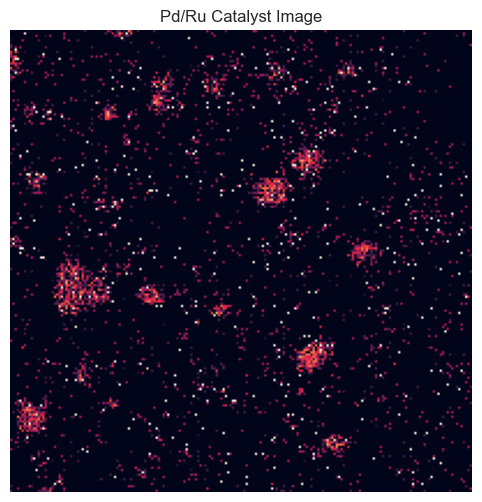

图像数组维度: (200, 200)


In [21]:
# —— Q4.1 读取并显示催化剂图像 ——
import matplotlib.pyplot as plt

# 读取图像
catalyst_img = plt.imread("catalyst.png")

# 显示图像
plt.figure(figsize=(8, 6))
plt.imshow(catalyst_img)
plt.title("Pd/Ru Catalyst Image")
plt.axis('off')
plt.show()

# 打印数组维度
print(f"图像数组维度: {catalyst_img.shape}")

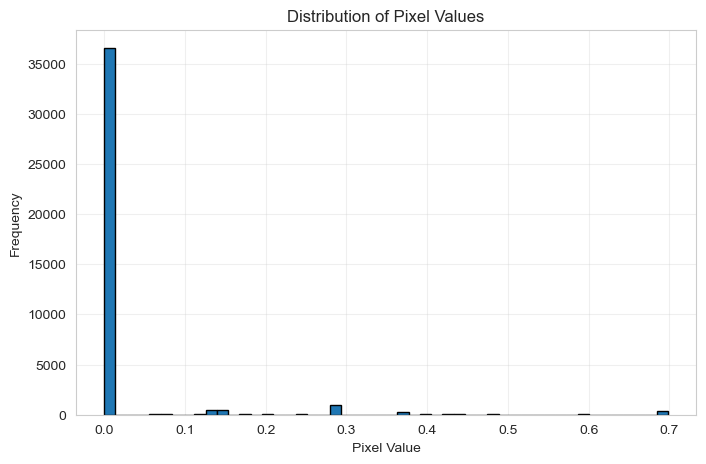

像素值范围: [0.0000, 0.6980]
像素值均值: 0.0258
像素值标准差: 0.0989


In [22]:
# —— Q4.2 绘制图像数组值的分布直方图 ——

# 展平数组
flattened_img = catalyst_img.flatten()

# 绘制直方图
plt.figure(figsize=(8, 5))
plt.hist(flattened_img, bins=50, edgecolor='black')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Distribution of Pixel Values')
plt.grid(alpha=0.3)
plt.show()

# 统计信息
print(f"像素值范围: [{flattened_img.min():.4f}, {flattened_img.max():.4f}]")
print(f"像素值均值: {flattened_img.mean():.4f}")
print(f"像素值标准差: {flattened_img.std():.4f}")

每个簇的数据点数量:
  簇 0: 37726
  簇 1: 1832
  簇 2: 442

背景簇标签: 0


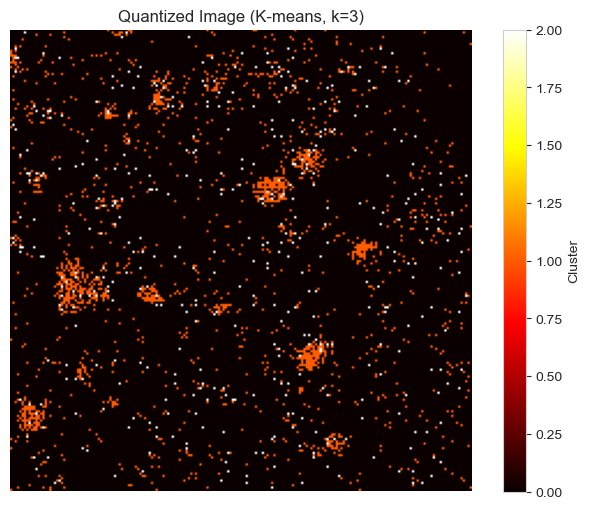

In [23]:
# —— Q4.3 K-means 量化图像 ——
from sklearn.cluster import KMeans

# 准备数据：将图像展平为 (n_pixels, 1)
X_img = catalyst_img.reshape(-1, 1)

# K-means 聚类，k=3
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_img)

# 统计每个簇的数据点数量
unique, counts = np.unique(labels, return_counts=True)
print("每个簇的数据点数量:")
for label, count in zip(unique, counts):
    print(f"  簇 {label}: {count}")

# 找到背景簇（数据点最多的簇）
background_label = unique[np.argmax(counts)]
print(f"\n背景簇标签: {background_label}")

# 重新映射标签：背景=0，其他两个簇=1和2
label_map = {background_label: 0}
other_labels = [l for l in unique if l != background_label]
label_map[other_labels[0]] = 1
label_map[other_labels[1]] = 2

# 应用映射
remapped_labels = np.array([label_map[l] for l in labels])

# Reshape 为原始图像维度
quantized_img = remapped_labels.reshape(catalyst_img.shape)

# 绘制量化后的图像
plt.figure(figsize=(8, 6))
plt.imshow(quantized_img, cmap='hot')
plt.title('Quantized Image (K-means, k=3)')
plt.colorbar(label='Cluster')
plt.axis('off')
plt.show()

非零像素点数量: 2274


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

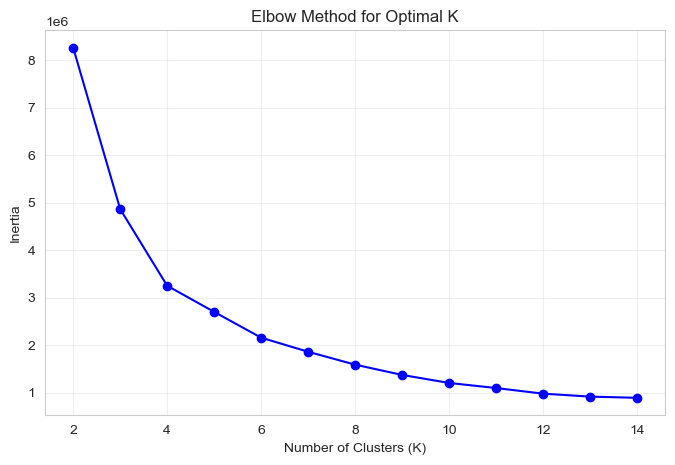

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



选择的K值: 6


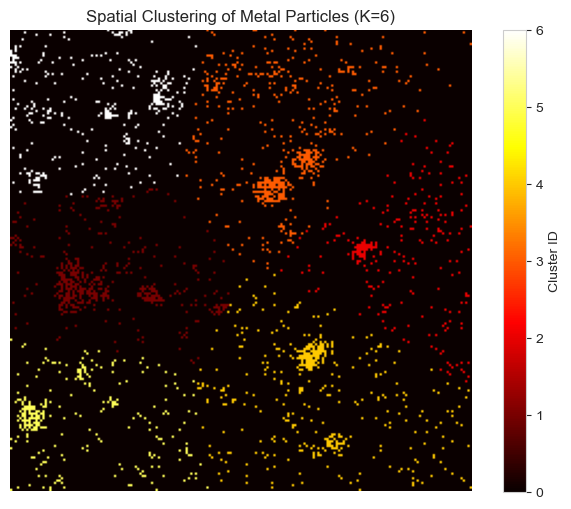

In [24]:
# —— Q4.4 K-means 聚类金属颗粒 ——
import os
os.environ['OMP_NUM_THREADS'] = '1'

# 提取非零像素的2D坐标
nonzero_indices = np.argwhere(quantized_img > 0)  # 返回 (row, col)
print(f"非零像素点数量: {len(nonzero_indices)}")

# 使用肘部法则确定最佳K值
inertias = []
K_range = range(2, 15)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(nonzero_indices)
    inertias.append(kmeans_temp.inertia_)

# 绘制肘部曲线
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(alpha=0.3)
plt.show()

# 选择最佳K值（根据肘部曲线）
best_k = 6  # 根据肘部曲线调整
print(f"\n选择的K值: {best_k}")

# 对非零坐标进行K-means聚类
kmeans_spatial = KMeans(n_clusters=best_k, random_state=42)
spatial_labels = kmeans_spatial.fit_predict(nonzero_indices)

# 将聚类标签映射回图像
clustered_img = np.zeros_like(quantized_img)
for idx, (row, col) in enumerate(nonzero_indices):
    clustered_img[row, col] = spatial_labels[idx] + 1  # +1 避免与背景0混淆

# 绘制聚类结果
plt.figure(figsize=(8, 6))
plt.imshow(clustered_img, cmap='hot')
plt.title(f'Spatial Clustering of Metal Particles (K={best_k})')
plt.colorbar(label='Cluster ID')
plt.axis('off')
plt.show()


K值选择依据:
- 通过肘部法则观察inertia下降趋势
- K=6时曲线出现明显拐点，增加K值收益递减
- 该K值能有效分离不同的金属颗粒团簇

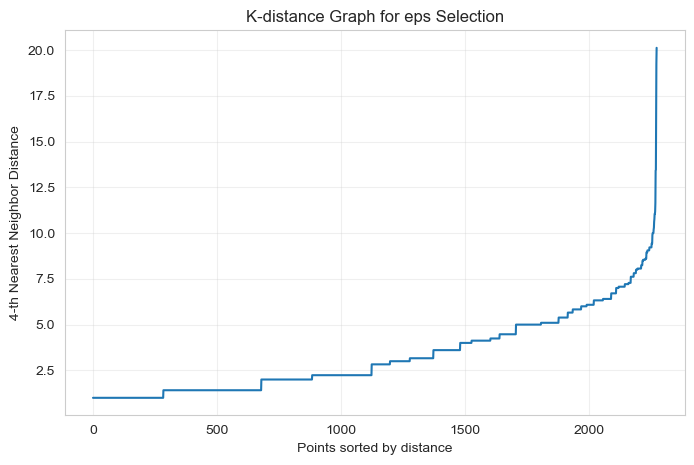

选择的eps值: 3.0
识别的簇数量: 85
噪声点数量: 796


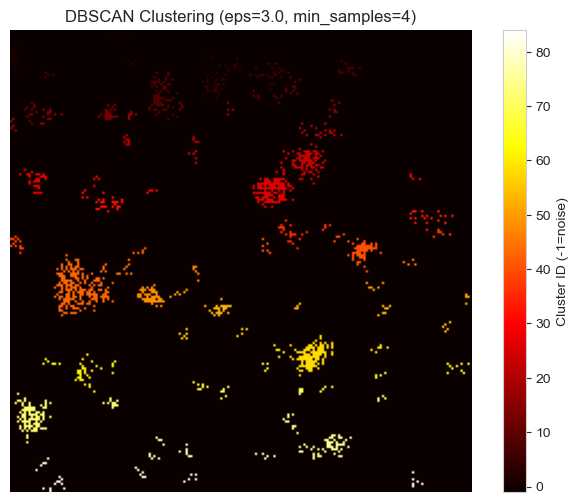

In [25]:
# —— Q4.5 DBSCAN 密度聚类 ——
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 使用K近邻距离图确定最佳eps
k = 4  # 最小样本数
nbrs = NearestNeighbors(n_neighbors=k).fit(nonzero_indices)
distances, indices = nbrs.kneighbors(nonzero_indices)

# 对每个点的第k个最近邻距离排序
k_distances = np.sort(distances[:, k-1])

# 绘制K-distance图
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.title('K-distance Graph for eps Selection')
plt.grid(alpha=0.3)
plt.show()

# 选择最佳eps（观察曲线的"肘部"）
best_eps = 3.0  # 根据K-distance图调整
print(f"选择的eps值: {best_eps}")

# DBSCAN聚类
dbscan = DBSCAN(eps=best_eps, min_samples=k)
dbscan_labels = dbscan.fit_predict(nonzero_indices)

# 统计聚类结果
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"识别的簇数量: {n_clusters}")
print(f"噪声点数量: {n_noise}")

# 将聚类标签映射回图像
dbscan_img = np.zeros_like(quantized_img) - 1  # 初始化为-1（背景）
for idx, (row, col) in enumerate(nonzero_indices):
    dbscan_img[row, col] = dbscan_labels[idx]

# 绘制DBSCAN聚类结果
plt.figure(figsize=(8, 6))
plt.imshow(dbscan_img, cmap='hot')
plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={k})')
plt.colorbar(label='Cluster ID (-1=noise)')
plt.axis('off')
plt.show()

eps选择逻辑:
- 使用K-distance图找到距离急剧上升的拐点
- eps=3.0能够连接密集区域的点，同时排除稀疏噪声
- 该参数有效识别了85个金属颗粒团簇

## K-means vs DBSCAN 方法对比：

## 聚类结果概览

| 方法 | 簇数量 | 噪声点 | 聚类依据 | 簇形状 |
|------|--------|--------|----------|--------|
| **K-means** | 6 (预设) | 0 (所有点都被分配) | 欧氏距离 | 球形/凸形 |
| **DBSCAN** | 85 (自动识别) | 796 | 密度连接 | 任意形状 |

## 详细对比分析

| 对比维度 | K-means | DBSCAN |
|----------|---------|--------|
| **簇的形状** | 强制形成凸形/球形簇，可能错误分割不规则颗粒 | 能识别任意形状的金属颗粒团簇 |
| **噪声处理** | 将所有点强制分配，包括孤立噪声点 | 自动识别并排除低密度噪声点 |
| **簇数量确定** | 需要预先指定K值，可能不符合真实颗粒数 | 根据密度自动发现簇数量 |
| **密度敏感性** | 假设簇大小相似，不适合密度不均的数据 | 能适应不同密度的颗粒分布 |


## 结论:

DBSCAN 更适合当前场景，因为:

  ✓ 金属颗粒形状不规则，DBSCAN能更好地捕捉真实边界
  
  ✓ 可自动识别噪声点（游离原子或测量误差）
  
  ✓ 无需预设颗粒数量，更符合实际探测场景
  
  ✓ 基于密度的定义更贴近物理意义（颗粒=高密度区域）